# Final data for ml model and Analysis

**for biometrics**

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
file_1 = [r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_0_500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_500000_1000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_1000000_1500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_1500000_1861108.csv']
df1 = pd.concat([pd.read_csv(file)  for file in file_1], ignore_index=True)

# Corrected column assignment based on the error and common CSV structures
# Assuming the CSV columns are: index, state, district, pincode, bio_age_5_17, bio_age_17_plus, date
df1.columns = [ 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_plus', 'date']
df1 = df1.drop('index', axis=1, errors='ignore')
df1['date'] = pd.to_datetime(df1['date'],  format='mixed', dayfirst=True, errors='coerce')

# Drop rows where 'date' is NaT
df1.dropna(subset=['date'], inplace=True)

# Single numeric column
df1['date_encoded'] = df1['date'].apply(lambda x: x.toordinal())
          ## biometrics
#####################################################3###################
df1 = df1.drop('date', axis=1)
df1 = df1.drop('state', axis=1)


le_district = LabelEncoder()
df1['district_label'] = le_district.fit_transform(df1['district'])
df1

,district,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
0,Haryana,Mahendragarh,123029,280,719163,17
1,Bihar,Madhepura,852121,144,719163,5
2,Jammu and Kashmir,Punch,185101,643,719163,20
3,Bihar,Bhojpur,802158,256,719163,5
4,Tamil Nadu,Madurai,625514,271,719163,40
...,...,...,...,...,...,...
1861103,West Bengal,Uttar Dinajpur,733201,4,719163,51
1861104,West Bengal,Uttar Dinajpur,733213,0,719163,51
1861105,West Bengal,West Midnapore,721304,0,719163,51
1861106,West Bengal,West Midnapore,721451,2,719163,51


**For demographic**

In [5]:
file_2 = [r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_0_500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_500000_1000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_1000000_1500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_1500000_2000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_2000000_2071700.csv']
df2 = pd.concat([pd.read_csv(file)  for file in file_2], ignore_index=True)

df2.columns = [ 'date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
df2 = df2.drop('index', axis=1, errors='ignore')
df2['date'] = pd.to_datetime(df2['date'], format='mixed', dayfirst=True)

# Single numeric column
df2['date_encoded'] = df2['date'].apply(lambda x: x.toordinal())
         ## demographics

##       dropping date #

df2 = df2.drop('date', axis=1)
df2 = df2.drop('state', axis=1)


le_district = LabelEncoder()
df2['district_label'] = le_district.fit_transform(df2['district'])
df2

,district,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
0,Gorakhpur,273213,49,529,739311,314
1,Chittoor,517132,22,375,739311,189
2,Rajkot,360006,65,765,739311,733
3,Srikakulam,532484,24,314,739311,858
4,Udaipur,313801,45,785,739311,909
...,...,...,...,...,...,...
2071695,West Midnapore,721212,0,12,739614,961
2071696,West Midnapore,721420,0,1,739614,961
2071697,West Midnapore,721424,0,5,739614,961
2071698,West Midnapore,721426,0,3,739614,961


## Filtering the data to District Wise

**For biographic**

In [6]:
# Biometrics file
df1 = df1.rename(columns={
    'bio_age_5_17': 'child_enroll_bio',
    'bio_age_17_plus': 'adult_enroll_bio'
})

# Demographic file
df2 = df2.rename(columns={
    'demo_age_5_17': 'child_enroll_demo',
    'demo_age_17_': 'adult_enroll_demo'   # note the underscore at the end
})

df1
df2

# Make sure both have the same essential columns
# common_cols = ['date', 'state', 'district', 'pincode', 'child_enroll_bio', 'adult_enroll_bio']
# df_bio = df1[common_cols]
# df_demo = df2[common_cols]

,district,pincode,child_enroll_demo,adult_enroll_demo,date_encoded,district_label
0,Gorakhpur,273213,49,529,739311,314
1,Chittoor,517132,22,375,739311,189
2,Rajkot,360006,65,765,739311,733
3,Srikakulam,532484,24,314,739311,858
4,Udaipur,313801,45,785,739311,909
...,...,...,...,...,...,...
2071695,West Midnapore,721212,0,12,739614,961
2071696,West Midnapore,721420,0,1,739614,961
2071697,West Midnapore,721424,0,5,739614,961
2071698,West Midnapore,721426,0,3,739614,961


In [7]:
# df1_karnataka = df1[df1['district']=='Yadgir']
# print(len(df1_karnataka))
# df1_karnataka

districts_to_include = ["Yadgir", "Bangalore", "Mysore", "Belgaum"]  # Add your districts here
df1_karnataka = df1[df1['district'].isin(districts_to_include)].copy()
df1_karnataka

,district,pincode,child_enroll_bio,adult_enroll_bio,date_encoded,district_label


**For Demographic**

In [8]:
# df2_karnataka = df2[df2['district']=='Yadgir']
# print(len(df2_karnataka))
# df2_karnataka

districts_to_include = ["Yadgir", "Bangalore", "Mysore", "Belgaum"]  # Add your districts here
df2_karnataka = df2[df2['district'].isin(districts_to_include)].copy()
df2_karnataka

,district,pincode,child_enroll_demo,adult_enroll_demo,date_encoded,district_label
20,Belgaum,591118,27,56,739311,108
51,Mysore,571121,10,104,739311,599
68,Belgaum,591232,65,116,739311,108
178,Mysore,570008,11,201,739311,599
194,Belgaum,591242,54,52,739311,108
...,...,...,...,...,...,...
2067918,Mysore,571124,0,9,739614,599
2067919,Mysore,571125,0,7,739614,599
2067920,Mysore,571602,0,6,739614,599
2068014,Yadgir,585201,0,2,739614,970


<Axes: title={'center': 'Biometric vs Demographic Enrolments by District'}, xlabel='district'>

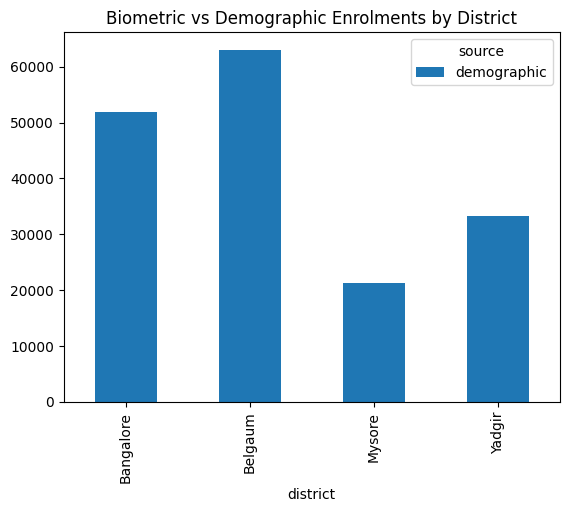

In [9]:
# Add source labels to distinguish the two original datasets
df1_karnataka['source'] = 'biometric'
df2_karnataka['source'] = 'demographic'

# Combine into one big DataFrame
df_combined = pd.concat([df1_karnataka, df2_karnataka], ignore_index=True)

df_combined.fillna(0, inplace=True)

# Create total enrolment columns
df_combined['total_child_enroll'] = df_combined['child_enroll_bio'] + df_combined['child_enroll_demo']
df_combined['total_adult_enroll'] = df_combined['adult_enroll_bio'] + df_combined['adult_enroll_demo']
df_combined['total_enroll'] = df_combined['total_child_enroll'] + df_combined['total_adult_enroll']

# Now you can group and plot
by_district = df_combined.groupby(['district', 'source'])['total_enroll'].sum().unstack()
by_district.plot(kind='bar', title='Biometric vs Demographic Enrolments by District')


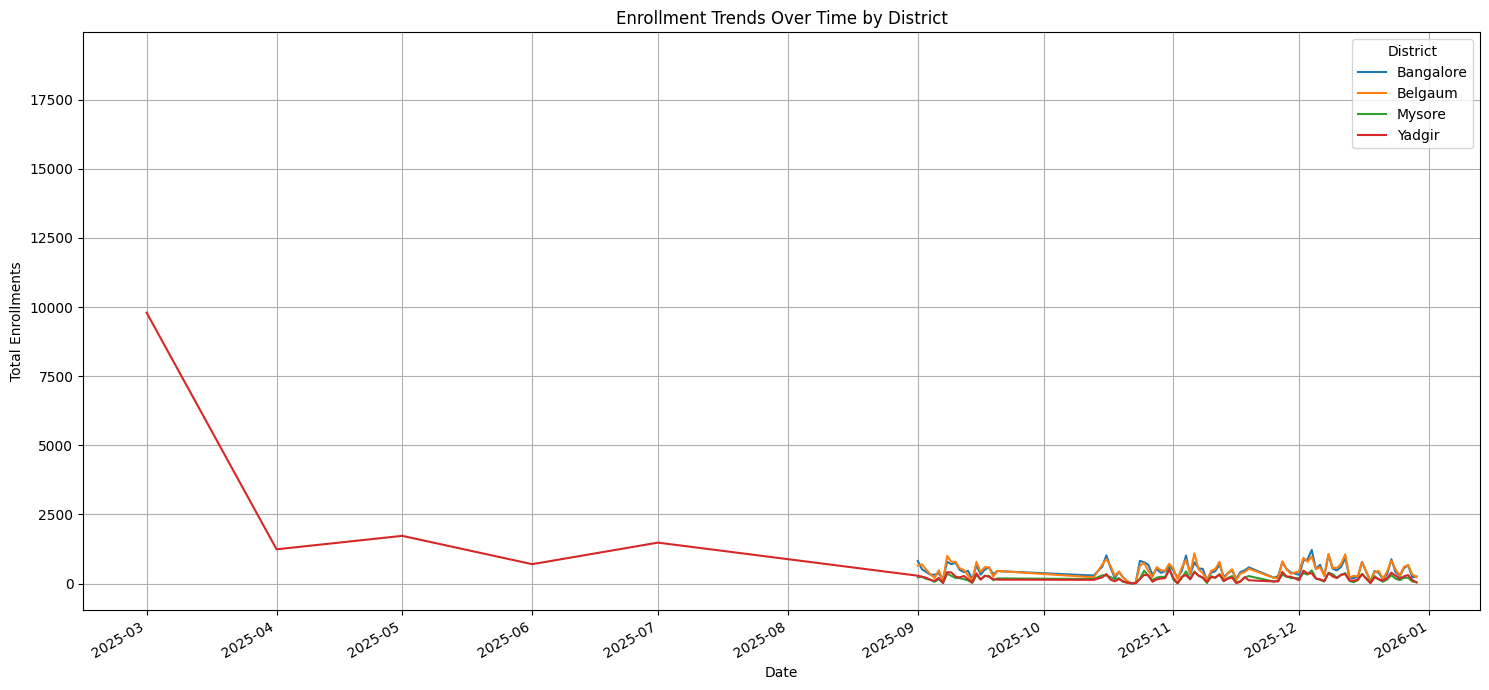

In [10]:
from datetime import date

# Convert 'date_encoded' back to datetime objects using date.fromordinal()
df_combined['date'] = df_combined['date_encoded'].apply(lambda x: pd.to_datetime(date.fromordinal(x)))

# Group by date and district to see trends over time
enrollment_trends = df_combined.groupby(['date', 'district'])['total_enroll'].sum().unstack()

# Plot the trends
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
enrollment_trends.plot(kind='line', ax=plt.gca())
plt.title('Enrollment Trends Over Time by District')
plt.xlabel('Date')
plt.ylabel('Total Enrollments')
plt.grid(True)
plt.legend(title='District')
plt.tight_layout()
plt.show()

Let's inspect the unique date values in `df1` and `df2` after initial parsing to understand the discrepancy in dates.

In [13]:
print('Unique dates in df1 (biometric) after initial parsing:')
# Reload df1 temporarily to check dates before dropping/encoding
temp_file_1 = [r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_0_500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_500000_1000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_1000000_1500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_biometric_1500000_1861108.csv']
temp_df1 = pd.concat(pd.read_csv(temp_file) for temp_file in temp_file_1 )
temp_df1.columns = [ 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_plus', 'date']
temp_df1['date'] = pd.to_datetime(temp_df1['date'], format='mixed', dayfirst=True, errors='coerce')
temp_df1.dropna(subset=['date'], inplace=True)
display(temp_df1['date'].unique())

print('\nUnique dates in df2 (demographic) after initial parsing:')
# Reload df2 temporarily to check dates before dropping/encoding
temp_file_2 = [r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_0_500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_500000_1000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_1000000_1500000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_1500000_2000000.csv',r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\api_data_aadhar_demographic_2000000_2071700.csv']
temp_df2 = pd.concat(pd.read_csv(temp_file) for temp_file in temp_file_2)
temp_df2.columns = ['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
temp_df2['date'] = pd.to_datetime(temp_df2['date'], format='mixed', dayfirst=True)
display(temp_df2['date'].unique())

Unique dates in df1 (biometric) after initial parsing:


<DatetimeArray>
['1970-01-01 00:00:00.000000577', '1970-01-01 00:00:00.000000369',
 '1970-01-01 00:00:00.000001091', '1970-01-01 00:00:00.000000980',
 '1970-01-01 00:00:00.000000815', '1970-01-01 00:00:00.000000529',
 '1970-01-01 00:00:00.000000143', '1970-01-01 00:00:00.000000298',
 '1970-01-01 00:00:00.000000214', '1970-01-01 00:00:00.000000085',
 ...
 '1970-01-01 00:00:00.000002023', '1970-01-01 00:00:00.000003229',
 '1970-01-01 00:00:00.000003926', '1970-01-01 00:00:00.000003246',
 '1970-01-01 00:00:00.000001802', '1970-01-01 00:00:00.000001996',
 '1970-01-01 00:00:00.000002286', '1970-01-01 00:00:00.000002741',
 '1970-01-01 00:00:00.000003083', '1970-01-01 00:00:00.000001747']
Length: 2212, dtype: datetime64[ns]


Unique dates in df2 (demographic) after initial parsing:


<DatetimeArray>
['2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-09-01 00:00:00',
 '2025-09-02 00:00:00', '2025-09-03 00:00:00', '2025-09-04 00:00:00',
 '2025-09-06 00:00:00', '2025-09-05 00:00:00', '2025-09-07 00:00:00',
 '2025-09-08 00:00:00', '2025-09-09 00:00:00', '2025-09-10 00:00:00',
 '2025-09-11 00:00:00', '2025-09-12 00:00:00', '2025-09-13 00:00:00',
 '2025-09-14 00:00:00', '2025-09-15 00:00:00', '2025-09-16 00:00:00',
 '2025-09-17 00:00:00', '2025-09-19 00:00:00', '2025-09-18 00:00:00',
 '2025-09-20 00:00:00', '2025-10-13 00:00:00', '2025-10-15 00:00:00',
 '2025-10-16 00:00:00', '2025-10-17 00:00:00', '2025-10-18 00:00:00',
 '2025-10-26 00:00:00', '2025-11-14 00:00:00', '2025-11-13 00:00:00',
 '2025-11-15 00:00:00', '2025-10-21 00:00:00', '2025-10-20 00:00:00',
 '2025-10-24 00:00:00', '2025-10-23 00:00:00', '2025-10-22 00:00:00',
 '2025-10-25 00:00:00', '2025-11-18 00:00:00', '2025-11-17 00:00:00',
 '20